# 08g — ESMFold Structural Validation

Direct continuation of 08f PEARL Pipeline 4. ESMFold is used only as an independent structural/conformational plausibility check, not as a peptide–EGFR affinity estimator. Short-peptide predictions can be poorly constrained; pLDDT/RMSD are descriptive QC signals only.

In [1]:
from pathlib import Path
import ast,json,re,sys,warnings
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
PREDICTION_MODE = "external"
EXTERNAL_PDB_DIR = Path(
    "/Users/robertobruzzese/Desktop/venv/outputs/esmfold_external"
)
# External mode: this directory must already contain real ESMFold PDB predictions.
# Do not create it automatically, because an empty directory is not a prediction.
if EXTERNAL_PDB_DIR is not None and not EXTERNAL_PDB_DIR.exists():
    raise FileNotFoundError(f"External PDB directory does not exist: {EXTERNAL_PDB_DIR}")
REFERENCE_PDB=None
OUTPUT_ROOT=Path("outputs/pipeline_4_ai_08g_esmfold_structural_validation")
TABLE_DIR=OUTPUT_ROOT/"tables"; FIGURE_DIR=OUTPUT_ROOT/"figures"; PDB_DIR=OUTPUT_ROOT/"predicted_pdb"
for d in (TABLE_DIR,FIGURE_DIR,PDB_DIR): d.mkdir(parents=True,exist_ok=True)
NB08F=Path("/Users/robertobruzzese/Downloads/08f_ProteinMPNN_Endpoint_Energy_Comparison_TEST=FALSE.ipynb")
if not NB08F.exists(): raise FileNotFoundError(NB08F)
nb=json.loads(NB08F.read_text()); src="\n".join("".join(x.get("source",[])) for x in nb["cells"] if x.get("cell_type")=="code")
def lit(n):
 tree=ast.parse(src)
 for node in tree.body:
  if isinstance(node,ast.Assign) and any(isinstance(t,ast.Name) and t.id==n for t in node.targets):
   return ast.literal_eval(node.value)
 raise KeyError(f"Could not extract {n} from 08f")
TARGET_CANDIDATES=lit("TARGET_CANDIDATES"); CANDIDATE_SEQUENCES=lit("CANDIDATE_SEQUENCES")
if not TARGET_CANDIDATES or set(TARGET_CANDIDATES)!=set(CANDIDATE_SEQUENCES): raise ValueError("08f candidate extraction failed")
print([(x,CANDIDATE_SEQUENCES[x]) for x in TARGET_CANDIDATES])


[('MPNN_NEW_01', 'TGPRNQYRDLP'), ('MPNN_NEW_05', 'IGPRHQYRDLP')]


In [3]:
from pathlib import Path

# Le predizioni sono state generate manualmente con ColabFold/ESMFold.
# Questa cella verifica soltanto che i PDB esistano e siano validi.

required_pdbs = []

for candidate_id in TARGET_CANDIDATES:
    pdb_path = (
        EXTERNAL_PDB_DIR
        / f"{candidate_id}.pdb"
    )

    required_pdbs.append(pdb_path)

    if not pdb_path.exists():
        raise FileNotFoundError(
            f"PDB mancante: {pdb_path}"
        )

    pdb_text = pdb_path.read_text(
        encoding="utf-8",
        errors="replace",
    )

    atom_lines = [
        line
        for line in pdb_text.splitlines()
        if line.startswith(("ATOM", "HETATM"))
    ]

    if len(atom_lines) == 0:
        raise ValueError(
            f"PDB non valido o vuoto: {pdb_path}"
        )

    print(
        f"PDB valido: {pdb_path.name} | "
        f"coordinate atomiche: {len(atom_lines)}"
    )

print("Tutte le predizioni ESMFold esterne sono disponibili.")

PDB valido: MPNN_NEW_01.pdb | coordinate atomiche: 92
PDB valido: MPNN_NEW_05.pdb | coordinate atomiche: 95
Tutte le predizioni ESMFold esterne sono disponibili.


In [4]:
from pathlib import Path

pdb_dir = Path(
    "/Users/robertobruzzese/Desktop/venv/outputs/esmfold_external"
)

for path in pdb_dir.glob("*.pdb"):
    print("\nFILE:", path)
    print("SIZE:", path.stat().st_size, "bytes")
    print(path.read_text()[:500])


FILE: /Users/robertobruzzese/Desktop/venv/outputs/esmfold_external/MPNN_NEW_05.pdb
SIZE: 7737 bytes
PARENT N/A
ATOM      1  N   ILE A   1     -12.181 -13.293  17.115  1.00 74.30           N  
ATOM      2  CA  ILE A   1     -12.092 -13.186  15.663  1.00 74.31           C  
ATOM      3  C   ILE A   1     -13.138 -12.197  15.152  1.00 75.49           C  
ATOM      4  CB  ILE A   1     -12.277 -14.560  14.982  1.00 70.25           C  
ATOM      5  O   ILE A   1     -14.317 -12.298  15.499  1.00 71.81           O  
ATOM      6  CG1 ILE A   1     -11.285 -15.579  15.557  1.00 61.66           C  
ATO

FILE: /Users/robertobruzzese/Desktop/venv/outputs/esmfold_external/MPNN_NEW_01.pdb
SIZE: 7494 bytes
PARENT N/A
ATOM      1  N   THR A   1       6.229   9.358  11.119  1.00 73.27           N  
ATOM      2  CA  THR A   1       5.056   9.083  10.298  1.00 73.35           C  
ATOM      3  C   THR A   1       5.254   9.608   8.879  1.00 76.24           C  
ATOM      4  CB  THR A   1       3.788   9.

## Input traceability and preliminary controls
Candidates and sequences are extracted from 08f source. The expected 08e topology/trajectory paths are recorded and checked, but 08g does not recompute endpoint energies.

In [5]:
MD_ROOT=Path("outputs/pipeline_4_ai_08e_top_mpnn_md/production_1ns")
rows=[]
for cid in TARGET_CANDIDATES:
 t=MD_ROOT/cid/"trajectory"; tops=[t/f"{cid}_protein_MDA_topology.pdb",t/f"{cid}_protein_topology.pdb"]; dcds=[t/f"{cid}_production_protein.dcd",t/f"{cid}_production_full.dcd"]
 rows.append({"candidate_id":cid,"sequence":CANDIDATE_SEQUENCES[cid],"topology_pdb":str(next((x for x in tops if x.exists()),'')),"trajectory_dcd":str(next((x for x in dcds if x.exists()),''))})
input_df=pd.DataFrame(rows); display(input_df)


,candidate_id,sequence,topology_pdb,trajectory_dcd
0,MPNN_NEW_01,TGPRNQYRDLP,outputs/pipeline_4_ai_08e_top_mpnn_md/producti...,outputs/pipeline_4_ai_08e_top_mpnn_md/producti...
1,MPNN_NEW_05,IGPRHQYRDLP,outputs/pipeline_4_ai_08e_top_mpnn_md/producti...,outputs/pipeline_4_ai_08e_top_mpnn_md/producti...


In [6]:
# External mode is intentional on this macOS environment: local OpenFold/ESMFold
# requires CUDA/nvcc and is not used here.
if PREDICTION_MODE != "external":
    raise ValueError("This corrected notebook is configured for external ESMFold PDBs. Set PREDICTION_MODE='external'.")
required_pdbs=[EXTERNAL_PDB_DIR/f"{cid}.pdb" for cid in TARGET_CANDIDATES]
missing=[str(p) for p in required_pdbs if not p.exists()]
if missing:
    raise FileNotFoundError("Missing external ESMFold predictions:\n"+"\n".join(missing)+"\nCreate/download these real PDBs before continuing.")
print("External ESMFold predictions found:", EXTERNAL_PDB_DIR.resolve())


External ESMFold predictions found: /Users/robertobruzzese/Desktop/venv/outputs/esmfold_external


## Prediction and metrics
External mode requires `<candidate_id>.pdb`. Local mode uses `esm.pretrained.esmfold_v1()` and may require substantial memory.

In [7]:
from Bio.PDB import PDBParser
parser=PDBParser(QUIET=True)
preds=[]
for cid in TARGET_CANDIDATES:
 out=PDB_DIR/f"{cid}.pdb"
 if PREDICTION_MODE=="external":
  q=Path(EXTERNAL_PDB_DIR)/f"{cid}.pdb"
  if not q.exists(): raise FileNotFoundError(q)
  out.write_bytes(q.read_bytes())
 else: raise RuntimeError("Local prediction disabled; supply external PDBs.")
 st=parser.get_structure(cid,str(out)); ca=[a for a in st.get_atoms() if a.get_name()=="CA"]; b=np.array([a.get_bfactor() for a in ca],float)
 preds.append({"candidate_id":cid,"sequence":CANDIDATE_SEQUENCES[cid],"pdb_path":str(out),"n_atoms":len(list(st.get_atoms())),"n_CA":len(ca),"mean_pLDDT_Bfactor":float(np.mean(b)) if len(b) else np.nan,"pLDDT_available":bool(len(b))})
result_df=pd.DataFrame(preds); display(result_df)


,candidate_id,sequence,pdb_path,n_atoms,n_CA,mean_pLDDT_Bfactor,pLDDT_available
0,MPNN_NEW_01,TGPRNQYRDLP,outputs/pipeline_4_ai_08g_esmfold_structural_v...,92,11,72.559091,True
1,MPNN_NEW_05,IGPRHQYRDLP,outputs/pipeline_4_ai_08g_esmfold_structural_v...,95,11,67.273636,True


## Optional reference comparison
RMSD is computed only when a reference PDB is supplied and CA counts match. It is a geometric descriptor, not affinity evidence.

,check,pass
0,08f_candidates_traced,True
1,prediction_pdbs_present,True
2,short_peptide_caveat_recorded,True


ALL QC PASSED: True


105

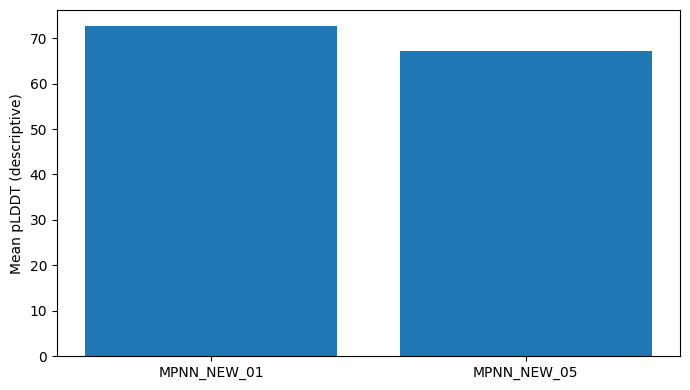

In [8]:
def rmsd(a,b):
 x=np.array([z.coord for z in parser.get_structure("r",str(a)).get_atoms() if z.get_name()=="CA"]); y=np.array([z.coord for z in parser.get_structure("p",str(b)).get_atoms() if z.get_name()=="CA"])
 if len(x)!=len(y) or len(x)<3:return np.nan
 x=x-x.mean(0); y=y-y.mean(0); u,s,v=np.linalg.svd(y.T@x); d=np.sign(np.linalg.det(u@v)); R=u@np.diag([1,1,d])@v; return float(np.sqrt(np.mean(np.sum((x-y@R)**2,axis=1))))
result_df["reference_CA_RMSD_A"]=[rmsd(REFERENCE_PDB,p) if REFERENCE_PDB else np.nan for p in result_df.pdb_path]
result_df["plausibility_rank"]=result_df["mean_pLDDT_Bfactor"].rank(ascending=False,na_option="bottom",method="min").astype(int)
result_df.to_csv(TABLE_DIR/"08g_ESMFold_structural_validation_summary.csv",index=False)
fig,ax=plt.subplots(figsize=(7,4)); ax.bar(result_df.candidate_id,result_df.mean_pLDDT_Bfactor); ax.set_ylabel("Mean pLDDT (descriptive)"); fig.tight_layout(); fig.savefig(FIGURE_DIR/"08g_mean_plddt.png",dpi=220)
qc=pd.DataFrame([{"check":"08f_candidates_traced","pass":True},{"check":"prediction_pdbs_present","pass":all(Path(x).exists() for x in result_df.pdb_path)},{"check":"short_peptide_caveat_recorded","pass":True}]); qc.to_csv(TABLE_DIR/"08g_QC.csv",index=False); display(qc); print("ALL QC PASSED:",bool(qc['pass'].all()))
(OUTPUT_ROOT/"08g_structural_validation_report.md").write_text("ESMFold is a structural plausibility check only; short-peptide pLDDT/RMSD are not affinity measurements.\n")
